In [2]:
# config.py
import torch
import os
import matplotlib.pyplot as plt
from PIL import Image

# --- Training Hyperparameters ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE_GEN = 1e-4
LEARNING_RATE_DISC = 1e-4
BATCH_SIZE = 16
NUM_EPOCHS_PRETRAIN = 50
NUM_EPOCHS_GAN = 100
HIGH_RES_SIZE = 96  # As per the paper
LOW_RES_SIZE = HIGH_RES_SIZE // 4
NUM_WORKERS = 4
LAMBDA_VGG = 1.0  # Weight for VGG/content loss
LAMBDA_ADV = 1e-3  # Weight for adversarial loss

os.makedirs("saved_models", exist_ok=True)

# --- Model Paths ---
PRETRAINED_GEN_PATH = "saved_models/srresnet_pretrained.pth"
GEN_PATH = "saved_models/generator.pth"
DISC_PATH = "saved_models/discriminator.pth"

# --- Dataset Paths ---
TRAIN_DIR = "/root/.cache/kagglehub/datasets/takihasan/div2k-dataset-for-super-resolution/versions/1/Dataset/DIV2K_train_HR"
TEST_DIR = "/root/.cache/kagglehub/datasets/takihasan/div2k-dataset-for-super-resolution/versions/1/Dataset/DIV2K_valid_HR"

# set the repo name
model_name = "keanteng/srgan-div2k-0723-v2"

# Study

## From The Paper
```txt
 To discriminate real HR images from generated SR
 samples we train a discriminator network. The architecture
 is shown in Figure 4. We follow the architectural guidelines
 summarized by Radford et al. [44] and use LeakyReLU
 activation ( = 0.2) and avoid max-pooling throughout
 the network. The discriminator network is trained to solve
 the maximization problem in Equation 2. It contains eight
 convolutional layers with an increasing number of 3x3
 filter kernels, increasing by a factor of 2 from 64 to 512 ker
nels as in the VGG network [49]. Strided convolutions are
 used to reduce the image resolution each time the number
 of features is doubled. The resulting 512 feature maps are
 followed by two dense layers and a final sigmoid activation
 function to obtain a probability for sample classification.
```

### Why No Sigmoid?
```
The comment # No sigmoid here, handled by BCEWithLogitsLoss is crucial and indicates correct understanding. nn.BCEWithLogitsLoss internally applies the sigmoid activation for numerical stability before calculating the binary cross-entropy, so you should not apply nn.Sigmoid() at the end of the discriminator's forward method when using this loss function.
```

### What is LeakyReLU?
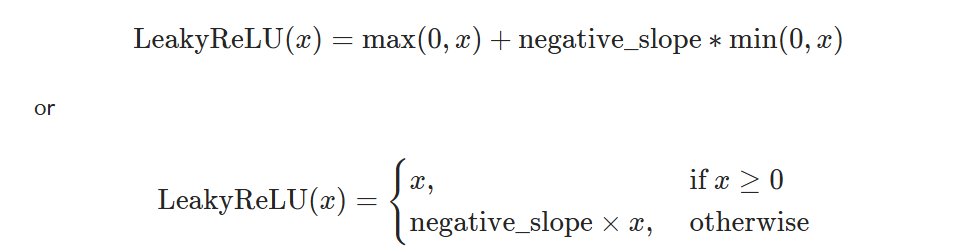

### Explanation
```python
def conv_block(in_feat, out_feat, stride=1):
    return nn.Sequential(
        nn.Conv2d(in_feat, out_feat, kernel_size=3, stride=stride, padding=1),
        nn.BatchNorm2d(out_feat),
        nn.LeakyReLU(0.2, inplace=True)
    )
```
- Input is 96 x 96, for Conv2D, output = `(input_size - kernel_size + 2 * padding) / stride + 1`
- So, output = `(96 - 3 + 2 * 1) / 1 + 1 = 96`
- Then go through batchnorm and LeakyReLU, which do not change the size.

```python
self.blocks = nn.Sequential(
    nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1),
    nn.LeakyReLU(0.2, inplace=True),

    conv_block(64, 64, stride=2),
    conv_block(64, 128, stride=1),
    conv_block(128, 128, stride=2),
    conv_block(128, 256, stride=1),
    conv_block(256, 256, stride=2),
    conv_block(256, 512, stride=1),
    conv_block(512, 512, stride=2),
)
```
- Let's check the first block:
  - Input: 96 x 96
  - Conv2D: `(96 - 3 + 2 * 1) / 1 + 1 = 96`
  - LeakyReLU: No change, still 96 x 96
  - Then, output = (96 - 3 + 2 * 1) / 2 + 1 = 48.5 = 48 (floor) 
  - Then, output = (48 - 3 + 2 * 1) / 1 + 1 = 48
  - Next block: output = (48 - 3 + 2 * 1) / 2 + 1 = 24.5 = 24 (floor)
  - Next block: output = (24 - 3 + 2 * 1) / 1 + 1 = 24
  - Next block: output = (24 - 3 + 2 * 1) / 2 + 1 = 12.5 = 12 (floor)
  - Next block: output = (12 - 3 + 2 * 1) / 1 + 1 = 12
  - Next block: output = (12 - 3 + 2 * 1) / 2 + 1 = 6.5 = 6 (floor)

```python
self.classifier = nn.Sequential(
    nn.AdaptiveAvgPool2d(1), # Flattens the output
    nn.Conv2d(512, 1024, kernel_size=1),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(1024, 1, kernel_size=1)
)
```
- The `nn.AdaptiveAvgPool2d(1)` will reduce the spatial dimensions to 1x1, regardless of the input size.
- After this, the output will be 512 feature maps of size 1x1.
- The first `nn.Conv2d(512, 1024, kernel_size=1)` will not change the spatial dimensions, but will increase the number of channels to 1024.

In [3]:
from torch import nn

class Discriminator(nn.Module):
    """
    The Discriminator Network.
    It takes an image and outputs a probability of it being a real high-resolution image.
    """
    def __init__(self, in_channels=3):
        super(Discriminator, self).__init__()

        def conv_block(in_feat, out_feat, stride=1):
            return nn.Sequential(
                nn.Conv2d(in_feat, out_feat, kernel_size=3, stride=stride, padding=1),
                nn.BatchNorm2d(out_feat),
                nn.LeakyReLU(0.2, inplace=True)
            )

        self.blocks = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            conv_block(64, 64, stride=2),
            conv_block(64, 128, stride=1),
            conv_block(128, 128, stride=2),
            conv_block(128, 256, stride=1),
            conv_block(256, 256, stride=2),
            conv_block(256, 512, stride=1),
            conv_block(512, 512, stride=2),
        )

        # The paper mentions flattening and then two dense layers
        # The output size after convolutions on a 96x96 image is 512x6x6
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), # Flattens the output
            nn.Conv2d(512, 1024, kernel_size=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(1024, 1, kernel_size=1)
        )

    def forward(self, x):
        batch_size = x.size(0) # access  the first dimension of the input tensor which is the batch size
        out = self.blocks(x)
        out = self.classifier(out)
        return out.view(batch_size, -1) # No sigmoid here, handled by BCEWithLogitsLoss

### Check The Classifier

- After going through adaptive average pooling, output will be 512 feature maps of size 1x1.
- The first `nn.Conv2d(512, 1024, kernel_size=1)` will not change the spatial dimensions, but will increase the number of channels to 1024.
    - output = (1 - 1 + 2 * 0) / 1 + 1 = 1
- The second `nn.Conv2d(1024, 1, kernel_size=1)` will reduce the number of channels to 1, but will not change the spatial dimensions.
    - output = (1 - 1 + 2 * 0) / 1 + 1 = 1  


In [4]:
from torch import nn
class Example(nn.Module):
    def __init__(self):
        super().__init__()
        self.test = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Flattens the output becomes 1 by 1
            nn.Conv2d(512, 1024, kernel_size=1),
            nn.Conv2d(1024, 1, kernel_size=1)
        )
    def forward(self, x):
        out = self.test(x)
        return out

In [5]:
in_channels = 512  # Number of input channels
batch_size = 3  # Number of samples in a batch
height = 3  # Height of the input feature map
width = 3  # Width of the input feature map

# Create an instance of the model
model = Example()

# Create a dummy input tensor
# Shape: (batch_size, in_channels, height, width)
dummy_input = torch.randn(batch_size, in_channels, height, width)

print(f"Input shape: {dummy_input.shape}")
print(f"Input: {dummy_input}")

# Pass the input through the conv_block1
output = model(dummy_input)

print(f"Output shape: {output.shape}")
print(f"Output: {output}")

Input shape: torch.Size([3, 512, 3, 3])
Input: tensor([[[[ 0.9579,  0.0962,  2.9601],
          [-0.0668,  0.3290,  0.3836],
          [ 0.6149,  1.1866, -0.4709]],

         [[ 0.3541,  0.6300, -2.2660],
          [ 0.2449, -0.2068, -0.5791],
          [-0.7248, -2.4703, -0.5482]],

         [[ 1.7992,  1.9635,  1.4871],
          [-0.4131,  2.4472,  0.3083],
          [ 0.7158, -1.2187,  0.0501]],

         ...,

         [[ 1.0750,  0.7321, -0.4635],
          [-0.9315, -0.8870,  0.0506],
          [ 0.3258, -2.0289, -1.4970]],

         [[-0.6295, -1.9445, -0.5121],
          [-0.1895, -1.4013,  0.8963],
          [-0.8767,  0.4888, -0.0606]],

         [[-0.7353, -0.5976,  0.3311],
          [-0.0355,  0.2237,  0.0076],
          [ 0.9058, -0.8705,  1.4283]]],


        [[[ 1.2084,  1.1085,  0.1430],
          [ 0.0374,  0.1737,  0.9522],
          [-0.3521, -0.2138,  1.1469]],

         [[-1.3444,  1.2063,  1.8434],
          [ 0.8655, -0.8215,  0.1788],
          [ 2.4319,  0.02

In [25]:
class Example(nn.Module):
    def __init__(self):
        super().__init__()
        self.test = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Flattens the output becomes 1 by 1
            nn.Conv2d(512, 1024, kernel_size=1),
            nn.Conv2d(1024, 1, kernel_size=1)
        )
    def forward(self, x):
        out = self.test(x)
        return out.view(x.size(0), -1)

In [26]:
in_channels = 512  # Number of input channels
batch_size = 1  # Number of samples in a batch
height = 3  # Height of the input feature map
width = 3  # Width of the input feature map

# Create an instance of the model
model = Example()

# Create a dummy input tensor
# Shape: (batch_size, in_channels, height, width)
dummy_input = torch.randn(batch_size, in_channels, height, width)

print(f"Input shape: {dummy_input.shape}")
print(f"Input: {dummy_input}")

# Pass the input through the conv_block1
output = model(dummy_input)

print(f"Output shape: {output.shape}")
print(f"Output: {output}")

Input shape: torch.Size([1, 512, 3, 3])
Input: tensor([[[[-2.0608e+00, -1.6183e+00, -3.4180e+00],
          [ 1.1985e-01,  6.3857e-01, -8.0000e-01],
          [ 5.4222e-01, -1.8139e+00,  1.0531e-01]],

         [[ 2.0215e+00, -3.8658e-01,  1.1761e+00],
          [-6.8980e-01, -3.3591e-01, -3.4552e-01],
          [-1.0699e+00, -6.2995e-01,  1.4478e+00]],

         [[ 5.9185e-01, -2.6345e+00, -5.3447e-01],
          [-3.2116e-01, -3.6247e-01,  5.3169e-01],
          [-1.7058e+00, -1.0072e+00, -6.4112e-02]],

         ...,

         [[ 8.9597e-01, -1.6472e-01,  1.9072e-01],
          [-1.8513e+00,  1.2938e+00, -2.9020e+00],
          [-3.5833e-01, -2.8973e-02, -4.7981e-01]],

         [[ 9.0953e-01, -2.0098e+00,  1.0607e+00],
          [-1.0102e-01,  1.1254e+00,  1.0352e+00],
          [-1.8348e+00,  1.7879e-03, -7.5188e-01]],

         [[-9.6429e-01, -2.0293e-01,  4.2818e-01],
          [-8.6656e-01,  1.3740e+00, -5.0020e-01],
          [-1.1113e+00, -6.6843e-01, -2.3359e+00]]]])
Output 

In [34]:
x = torch.randn(1, 1, 1, 1)  # Example input tensor
print(x.view(x.size(0), -1))  # This will reshape the output to (batch_size, -1)

# The -1 tells PyTorch to infer the size of that dimension based on the other dimensions and the total number of elements.
# First number is the row size, second number is the column size.
x = torch.randn(1, 2, 1, 1)  # Example input tensor
print(x.view(x.size(0), -1))  # This will reshape the output to (batch_size, -1)

x = torch.randn(2, 2, 1, 1)  # Example input tensor
print(x.view(x.size(0), -1))  # This will reshape the output to (batch_size, -1)

tensor([[0.1742]])
tensor([[-2.3783,  1.0340]])
tensor([[-1.0421, -1.1852],
        [-0.6781,  0.3624]])
